In [7]:
import os
os.chdir("Data Sets")

In [8]:
import pandas as pd

df = pd.read_csv("all_athlete_games.csv", low_memory=False)

part1 = df[df["Age"].isna()][["Name","Age","Team","Sport","Event","Medal"]].head(3)
part2 = df[df["Sport"].isna()][["Name","Age","Team","Sport","Event","Medal"]].head(3)
part3 = df[(df["Year"]==2020) & (df["Medal"].notna())][["Name","Age","Team","Sport","Event","Medal"]].head(4)
sample = pd.concat([part1, part2, part3]).reset_index(drop=True)
print(sample)

                                 Name   Age           Team              Sport  \
0              Aristidis Akratopoulos   NaN         Greece             Tennis   
1              Aristidis Akratopoulos   NaN       Greece-3             Tennis   
2  Konstantinos "Kostas" Akratopoulos   NaN         Greece             Tennis   
3                    Artur ALEKSANYAN  32.0        Armenia                NaN   
4                      Malkhas AMOYAN  25.0        Armenia                NaN   
5                     Slavik GALSTYAN  27.0        Armenia                NaN   
6                           ABALO Luc  36.0         France           Handball   
7                       ABBOTT Monica  36.0  United States  Baseball/Softball   
8                    ABDELAZIZ Feryal  22.0          Egypt             Karate   
9                         ABDI Bashir  32.0        Belgium          Athletics   

                  Event   Medal  
0  Tennis Men's Singles     NaN  
1  Tennis Men's Doubles     NaN  
2  Ten

In [11]:
# Null handling:  Visualising nulls - isna(), notna()

# df.isna(), df.notna() - returns a same shaped dataframe of True/False

print(sample.isna())
print(sample.notna())

    Name    Age   Team  Sport  Event  Medal
0  False   True  False  False  False   True
1  False   True  False  False  False   True
2  False   True  False  False  False   True
3  False  False  False   True   True   True
4  False  False  False   True   True   True
5  False  False  False   True   True   True
6  False  False  False  False  False  False
7  False  False  False  False  False  False
8  False  False  False  False  False  False
9  False  False  False  False  False  False
   Name    Age  Team  Sport  Event  Medal
0  True  False  True   True   True  False
1  True  False  True   True   True  False
2  True  False  True   True   True  False
3  True   True  True  False  False  False
4  True   True  True  False  False  False
5  True   True  True  False  False  False
6  True   True  True   True   True   True
7  True   True  True   True   True   True
8  True   True  True   True   True   True
9  True   True  True   True   True   True


In [10]:
# counting nulls - per column

print(sample.isna().sum())
print((sample.isna().mean()*100).round(1))  # percentage of null values per column

Name     0
Age      3
Team     0
Sport    3
Event    3
Medal    6
dtype: int64
Name      0.0
Age      30.0
Team      0.0
Sport    30.0
Event    30.0
Medal    60.0
dtype: float64


In [13]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 6.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.5 MB 6.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 6.2 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 6.1 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 6.2 MB/s eta 0:00:

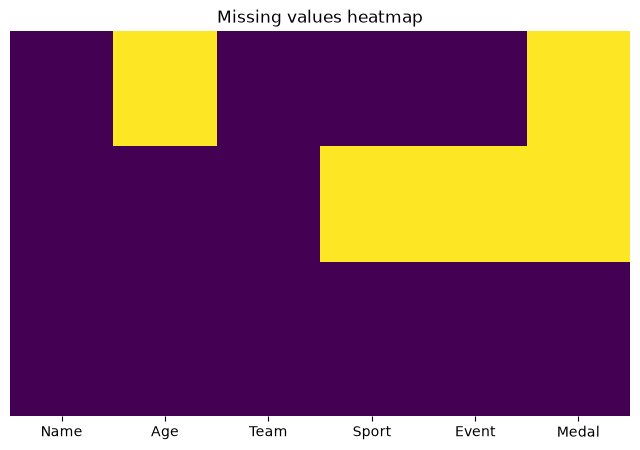

In [15]:
# Visualising nulls with sns.heatmap()

# syntax - sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(sample.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing values heatmap")
plt.show()

| Method                | What it shows                                          |
|----------------------------|------------------------------------------------------------------|
| df.isna()                     | True/False grid — True means missing                                 |
| df.notna()                      | True/False grid — True means present (the opposite)                    |
| df.isna().sum()                   | Missing value COUNT per column                                            |
| df.isna().mean()*100                | Missing value PERCENTAGE per column                                          |
| sns.heatmap(df.isna())                | Visual version of isna() — spot patterns at a glance                           |